# Spherical anomaly model

Forward model with an embedded spherical anomaly (eps_r = 20) above a homogeneous earth background.

The background reference is the analytical half-space solution (no anomaly). The difference between the anomaly and background responses is the target signature.

In [ ]:
import sys, os, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

# ── locate solver root relative to this notebook ────────────────────────────────
MASTER_PATH = Path(r"..\elfe3D_GPR").resolve()


# inputs
from elfe3d_gpr.inputs.survey import GPRSurvey
from elfe3d_gpr.inputs.anomalies import SphereAnomaly

# runner
from elfe3d_gpr.runner import ProjectPaths, run_tetgen, run_solver

# outputs
from elfe3d_gpr.outputs.fieldreader import AnalyticalLoader, ElfeLoader, CSVFieldLoader, GPRDataset
from elfe3d_gpr.outputs.postprocess import field_error, field_simple_error, error_stats
from visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot, 
                          ReceiverLineSimpleErrorPlot, SimpleErrorHistogramPlot)


---
## Paths and runtime configuration

In [ ]:
# ── set once per machine ───────────────────────────────────────────────────
paths = ProjectPaths(
    master_dir = MASTER_PATH,
    exec_rel   = r'elfe3D_GPR\elfe3d_gpr',
    use_wsl    = True,   # False if running the solver directly inside WSL
)

print('Solver root:', MASTER_PATH)
print('Executable:', paths.exec_path())


master   : f:\Projects\EMGeoInversion\elfe3D_GPR
exec     : f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\elfe3d_gpr


---
## 1 — Build and write inputs

Same background as the two-layered example, plus a `SphereAnomaly`

In [ ]:
f    = 100e6
wave = 3e8 / f

BASE_DIR = MASTER_PATH

survey = GPRSurvey.build(
    experiment_name="anomaly_sphere_hs",
    base_dir=BASE_DIR,

    # Domain
    x_e=[-wave/10, 1 + wave/10],
    y_e=[-wave/10, wave/10],
    z_e=[-1.0, wave/10],

    # Materials — air + homogeneous earth layers
    air_eps_r=1.0,
    air_sigma=1e-16,
    layer_thicknesses=[1.0],
    layer_eps_r=[4.0],
    layer_sigma=[1e-4],
    layer_mu_r=[1.0],
    layer_sigma_m=[0.0],

    anomalies=[
        SphereAnomaly(
            center=(0.0, 0.0, -0.7),
            radius=wave/16,
            properties=(20, 1e-4, 1.0, 0.0),   # (eps_r, sigma, mu_r, sigma_m)
        )
    ],

    # Source
    ricker_central_f=f,
    num_points_per_range=1,
    antenna_position=[0.0, 0.0, 0.025],
    source_type=6,
    current_direction=1,
    num_segments=1,
    s_f=250,
    bh_f=1.0,
    box_present=False,
    box_x=[-1 + 0.75, 1 + 0.375],
    m=5,

    # Receivers
    num_receivers_inline=48,
    num_receivers_endfire=0,
    num_receivers_oblique=0,

    # Solver
    solver_type=2,
    max_ref_steps=0,
    max_unknowns=5_000_000,
    accuracy_tol=3e-5,
    output_fields_vtk=1,

    # PML
    num_pml_layers=1,
    pml_layer_thickness=wave/10,
    pml_type="lin",
    pml_decay_type=1,

    least_samples_per_wavelength=20,
)

survey.generate()

print('poly :', survey.io.poly_file)


odepths: [np.float64(0.0375), np.float64(0.01875)]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
[0.0]
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_anomaly_sphere_hs.poly
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\elfe3D_input.txt
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\source.txt
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\regionparameters.txt
Input generation complete.
poly : f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_anomaly_sphere_hs.poly


---
## 2 — Mesh with TetGen

In [6]:
run_tetgen(paths, survey.io.poly_file)

── TetGen ────────────────────────────────────────────
   cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/in && /usr/bin/tetgen -pq1.2kAaen GPR_model_anomaly_sphere_hs.poly

Opening GPR_model_anomaly_sphere_hs.poly.
Delaunizing vertices...
Delaunay seconds:  0.016145
Creating surface mesh ...
Surface mesh seconds:  0.00497
Constrained Delaunay...
Constrained Delaunay seconds:  0.010459
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000785
Refining mesh...
Refinement seconds:  1.90301
Optimizing mesh...
Optimization seconds:  0.082931

Writing GPR_model_anomaly_sphere_hs.1.node.
Writing GPR_model_anomaly_sphere_hs.1.ele.
Writing GPR_model_anomaly_sphere_hs.1.face.
Writing GPR_model_anomaly_sphere_hs.1.edge.
Writing GPR_model_anomaly_sphere_hs.1.vtk.
Writing GPR_model_anomaly_sphere_hs.1.neigh.

Output seconds:  1.66132
Total running seconds:  3.67997

Statistics:

  Input points: 2788
  Input facets: 5238
  Input segments: 8009
  

---
## 3 — Run solver

In [12]:
run_solver(paths,survey)

── elfe3d_gpr ────────────────────────────────────────
   wsl bash -c cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR && /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/elfe3d_gpr

***************************************
GPR forward modelling with elfe3D_GPR
***************************************
Your forward problem is solved with
 MUMPS
*************************************
Reading refinement information
Your mesh will be refined
 for             0 refinement steps
 or until     5000000 unknowns
 with error estim. method           3
 with refinement strategy           1
Your output files will be generated in: /out
Field components in the domain will be in *.vtk file in: /in
*************************************
Reading model definitions
Your input meshfile is called
 in/GPR_model_anomaly_sphere_hs.                   
Your mesh has
       89925 Nodes
      539011 Elements
      636965 Edges (dof)
*************************************
Assembling connectivity arrays
Calcul

---
## 4 — Load results

In [4]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
print('reading:', result_txt)

ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D sphere anomaly',
    num_endfire = 48,
).endfire()

print(f'r : {ef.r.min():.3f} – {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


reading: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_anomaly_sphere_hs\electric_fields_receiver_line.txt
r : 0.100 – 1.000 m   (48 receivers)


---
## 5 — Background reference

In [6]:
# Background reference = two-layer model without the anomaly
# Same CSV as the two-layered example — the anomaly response is the
# difference between this and the anomaly run.
ANALYTICAL_DIR  = r'F:\Projects\EMGeoInversion\elfe3D_GPR\data\data_semi_analytical'
ANOMALY_DIR     = r'F:\Projects\EMGeoInversion\elfe3D_GPR\data\data_miepython'

bg = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_4_100MHz_NR.csv'),
    label='Background (Evert)',
).endfire()


anomaly_data = CSVFieldLoader(
    os.path.join(ANOMALY_DIR, 'endfire_electric_field.csv'),
    label='Anomaly',
)


---
## 6 — Anomaly vs background comparison

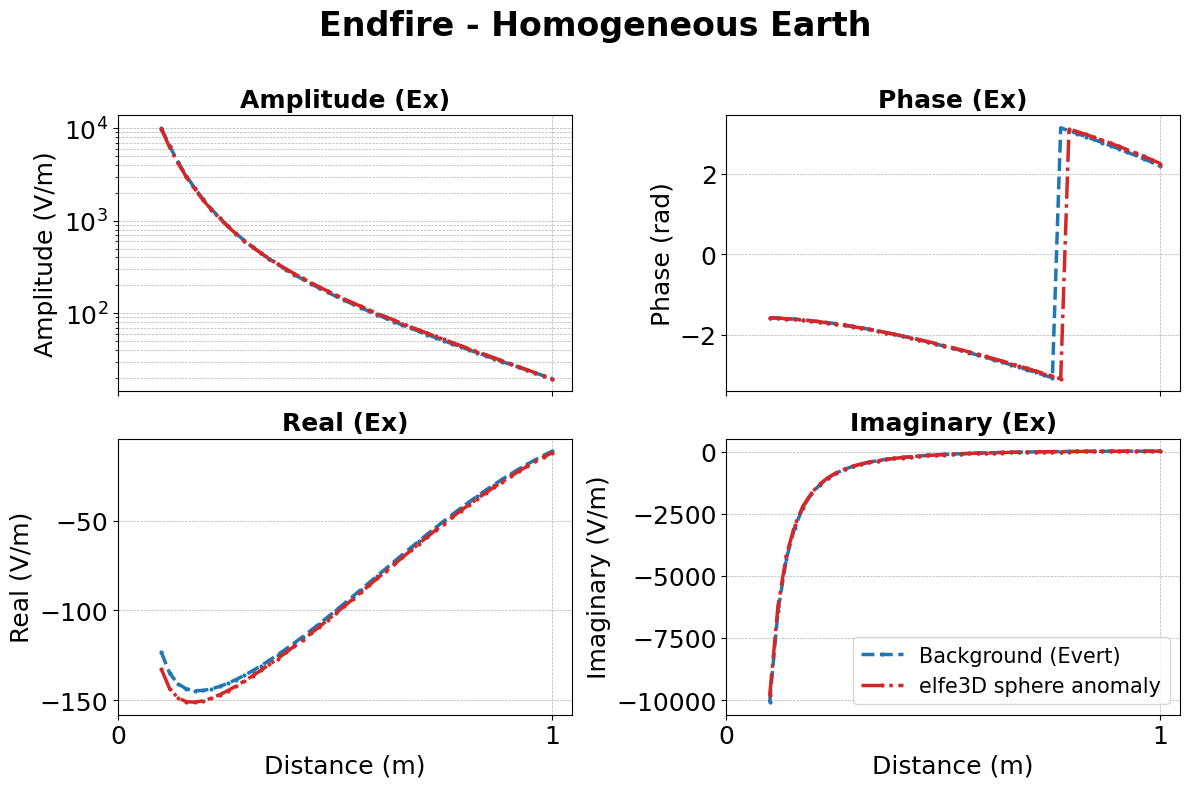

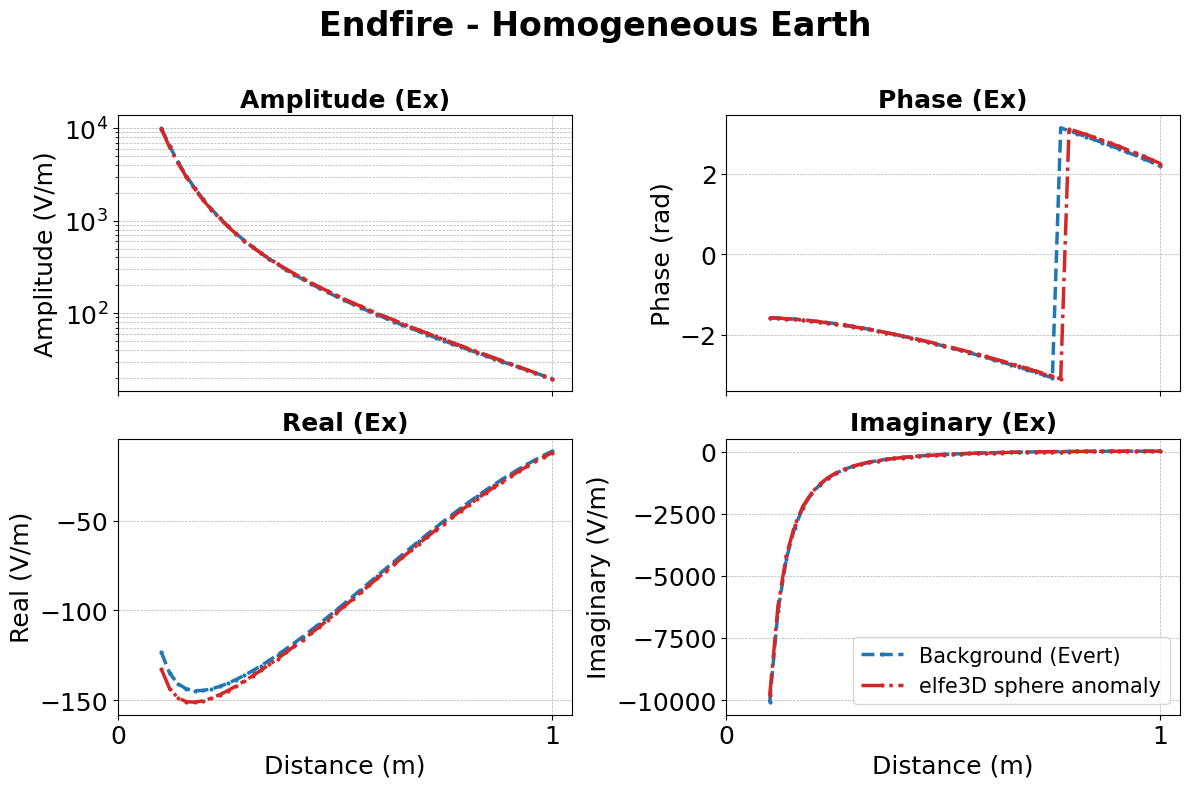

In [7]:
ReceiverLinePlot([bg, ef]).plot(suptitle="Endfire - Homogeneous Earth")

## Anomaly response  (difference from background)

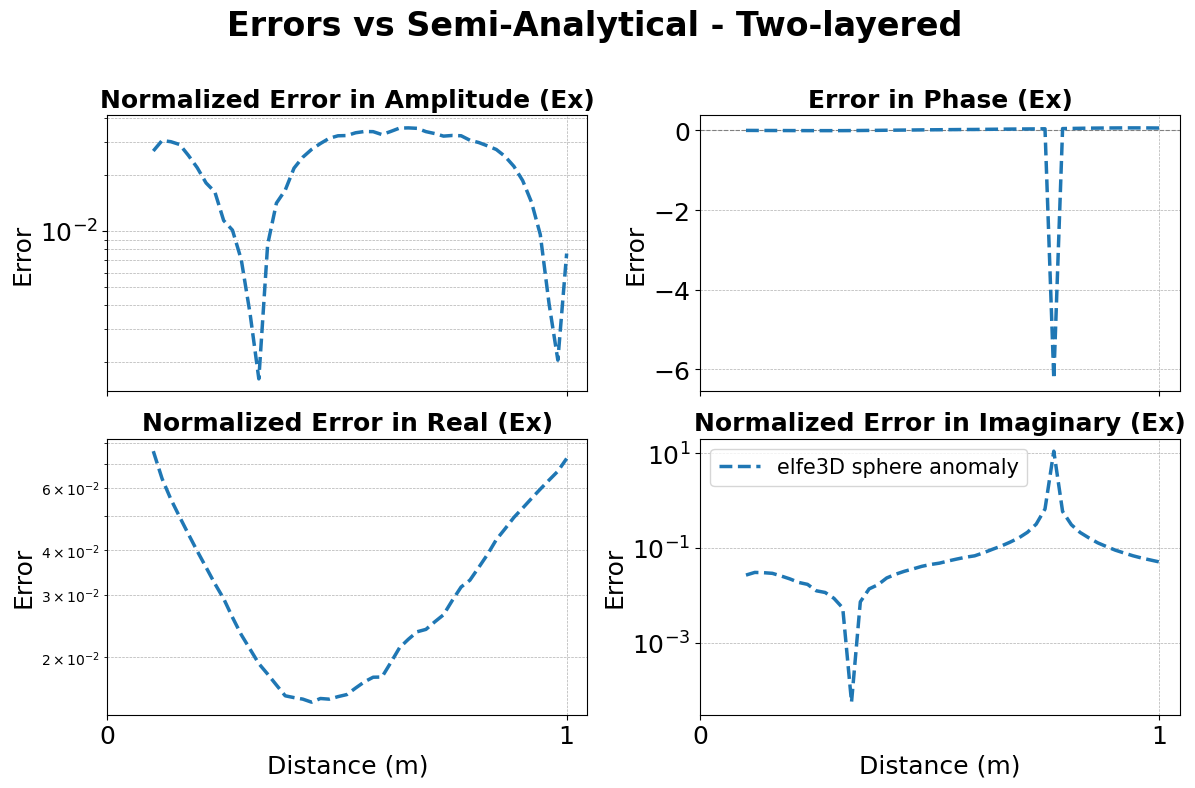

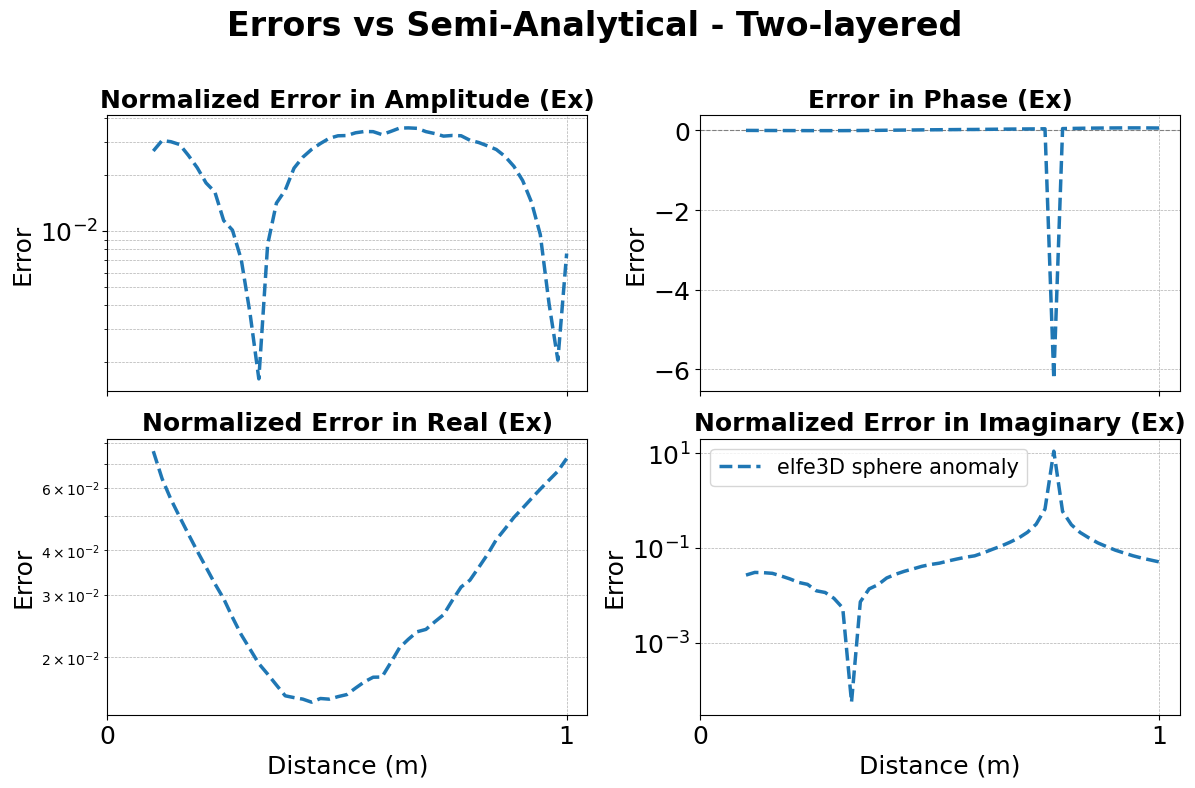

In [8]:
ReceiverLineErrorPlot([ef], reference=bg).plot(suptitle="Errors vs Semi-Analytical - Two-layered")

## Combined (fields + anomaly response)

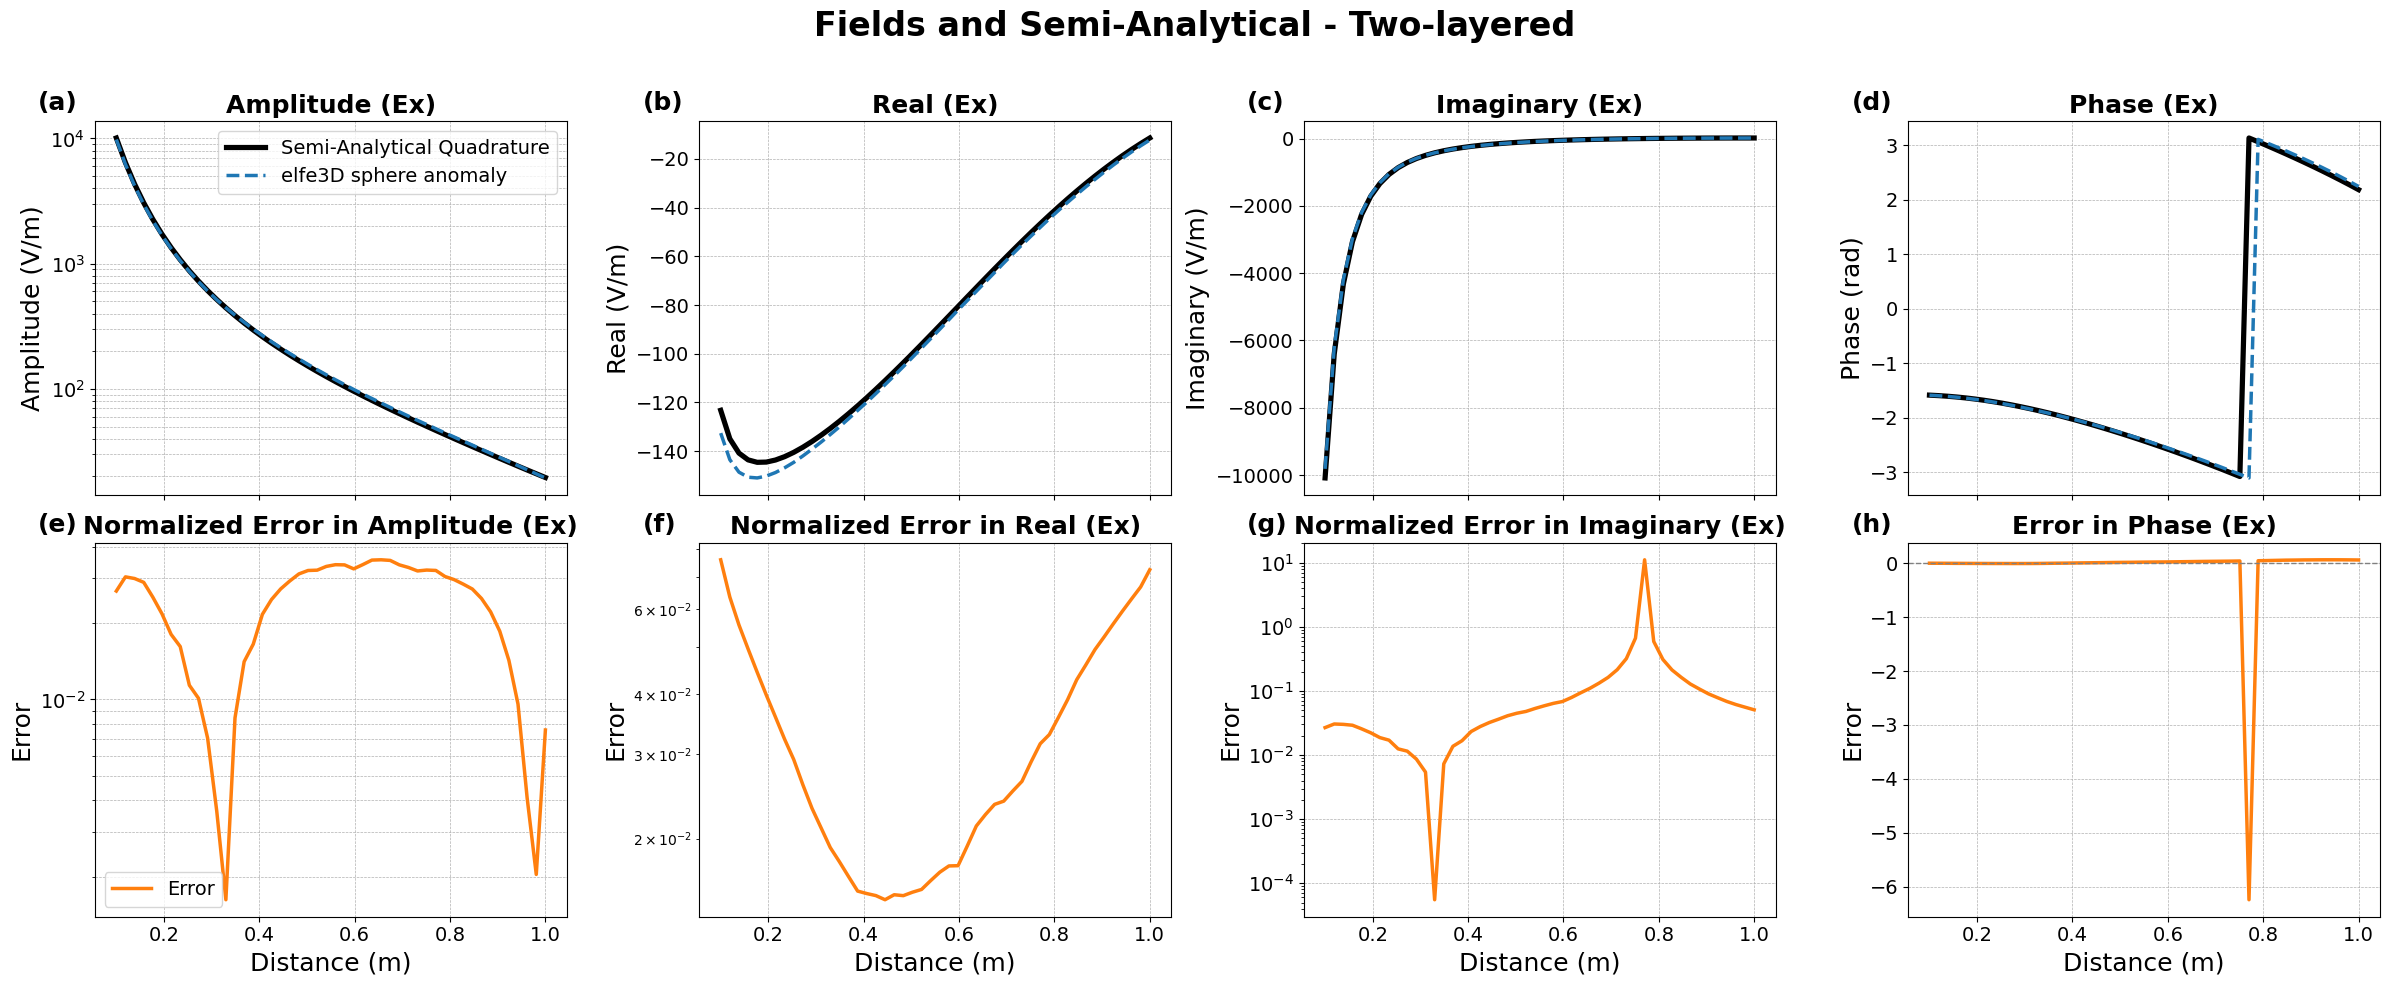

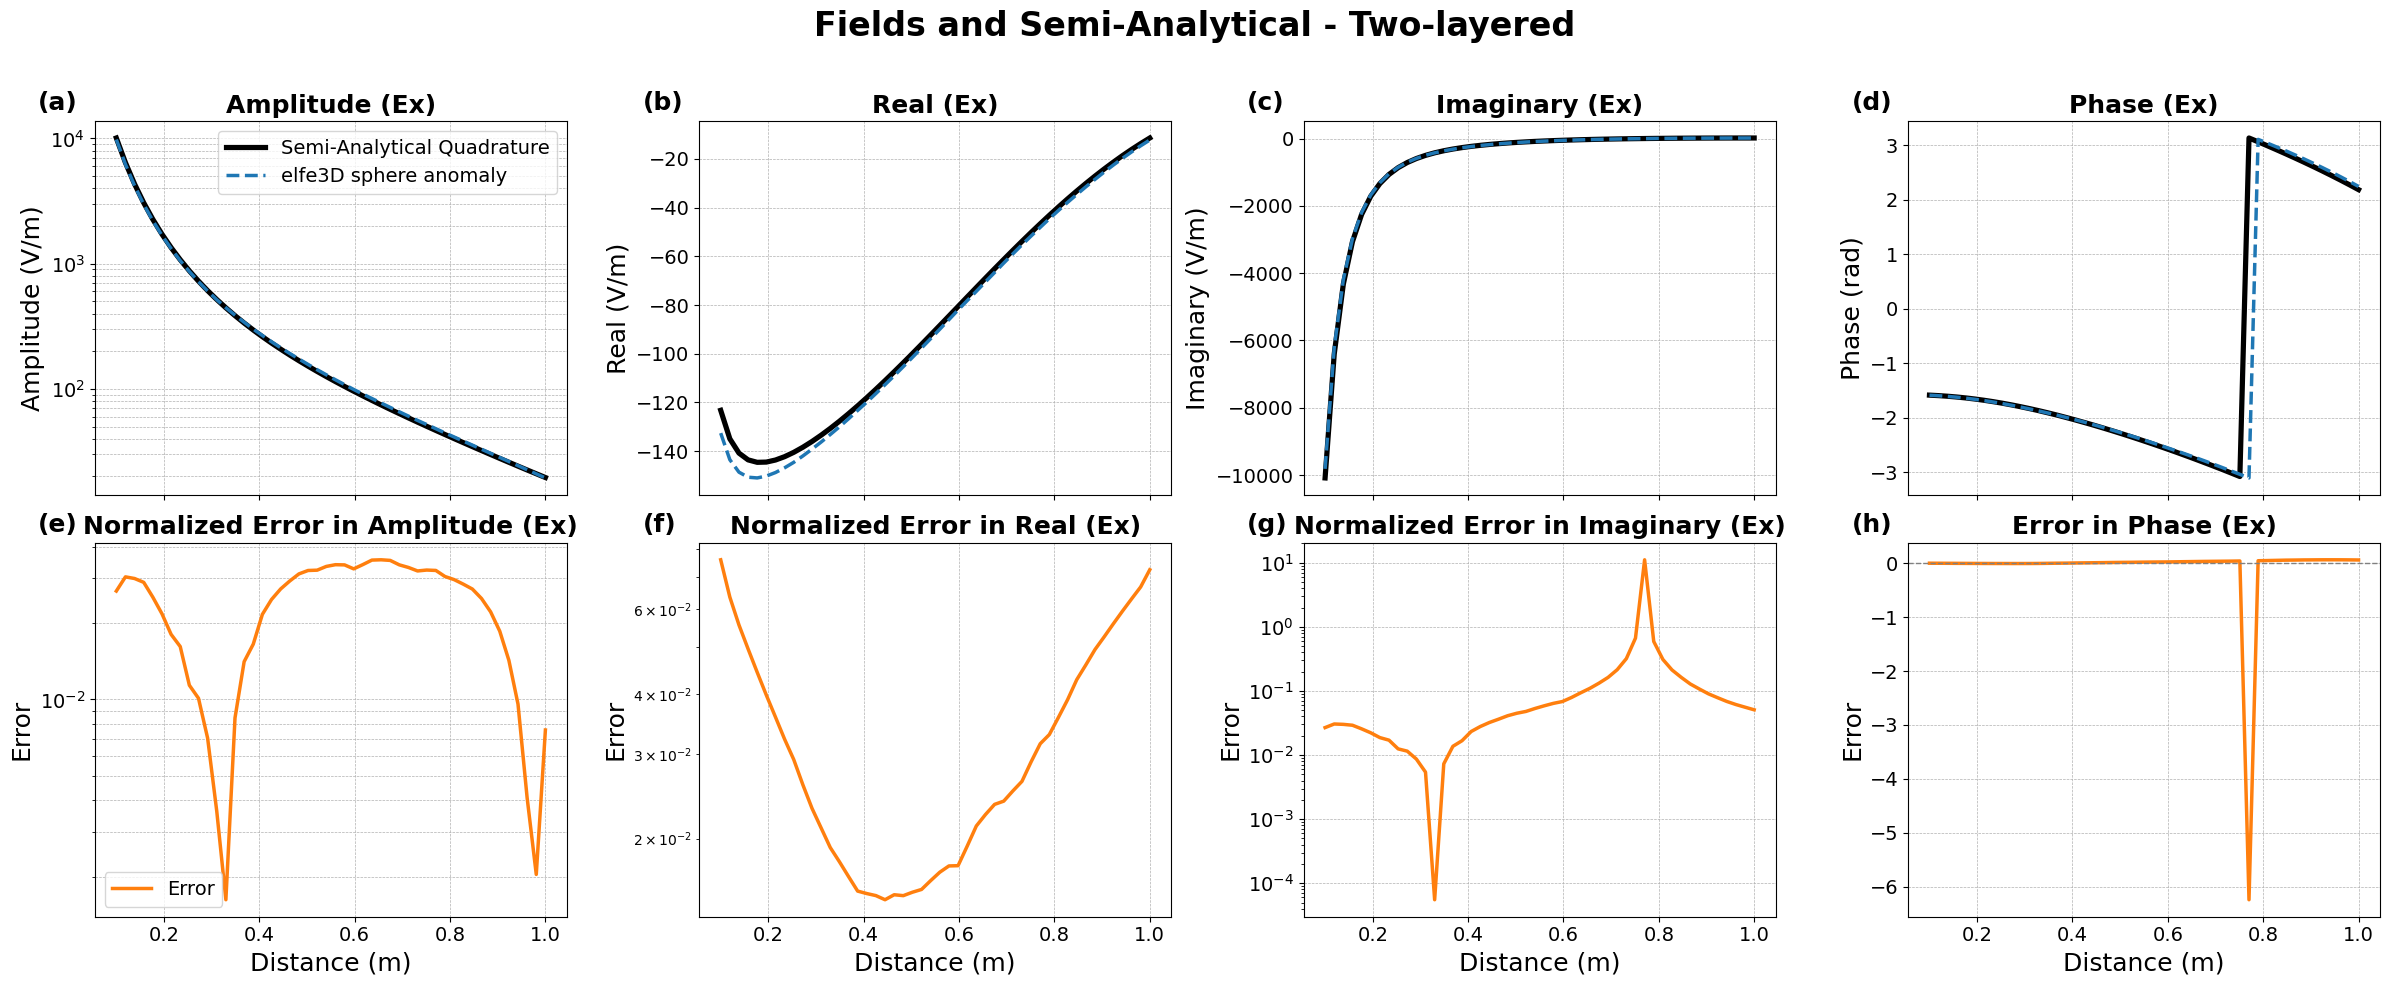

In [9]:
ReceiverLineCombined(ef, bg).plot(suptitle="Fields and Semi-Analytical - Two-layered")

## Response distribution histogram

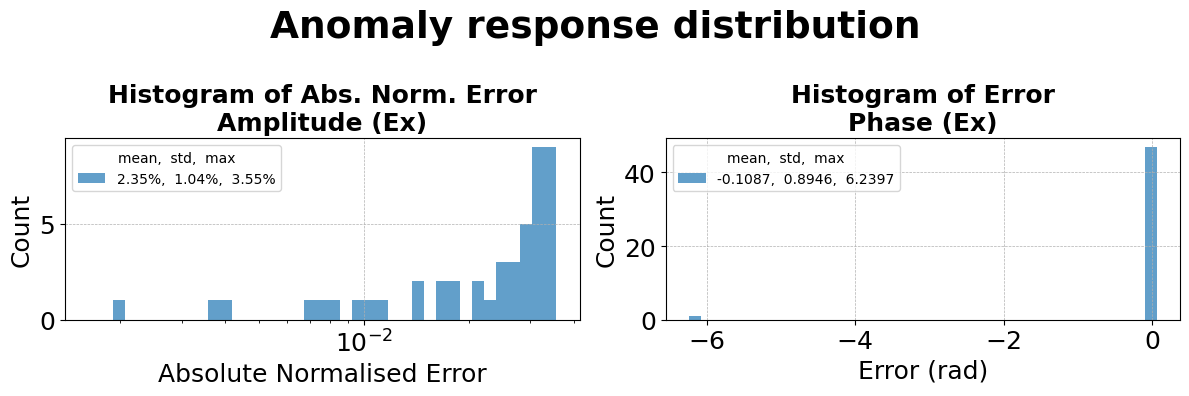

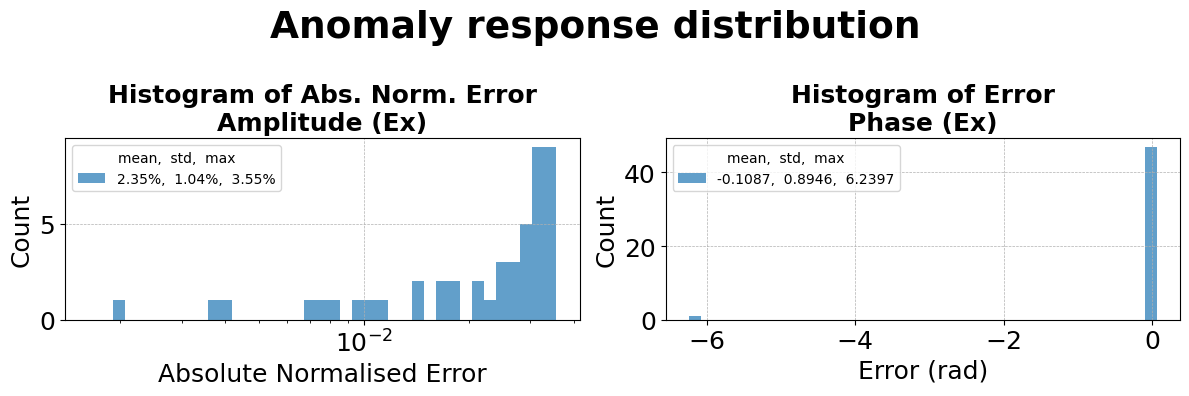

In [10]:
ErrorHistogramPlot([ef], reference=bg).plot(suptitle='Anomaly response distribution',)

## Printed anomaly response summary

In [11]:
qty_names = ['Amplitude', 'Phase', 'Real', 'Imaginary']
print('Anomaly response (relative to two-layer background)\n')
for qi, name in enumerate(qty_names):
    err = field_error(bg, ef, qi)
    m, s, mx = error_stats(err)
    scale, unit = (100, '%') if qi != 1 else (1, 'rad')
    print(f'  {name:12s}:  mean={m*scale:.3f}{unit}  '
          f'std={s*scale:.3f}{unit}  max={mx*scale:.3f}{unit}')


Anomaly response (relative to two-layer background)

  Amplitude   :  mean=2.347%  std=1.043%  max=3.554%
  Phase       :  mean=-0.109rad  std=0.895rad  max=6.240rad
  Real        :  mean=3.290%  std=1.753%  max=7.600%
  Imaginary   :  mean=32.442%  std=157.834%  max=1110.683%


## Finding the Sphere's Field Signature

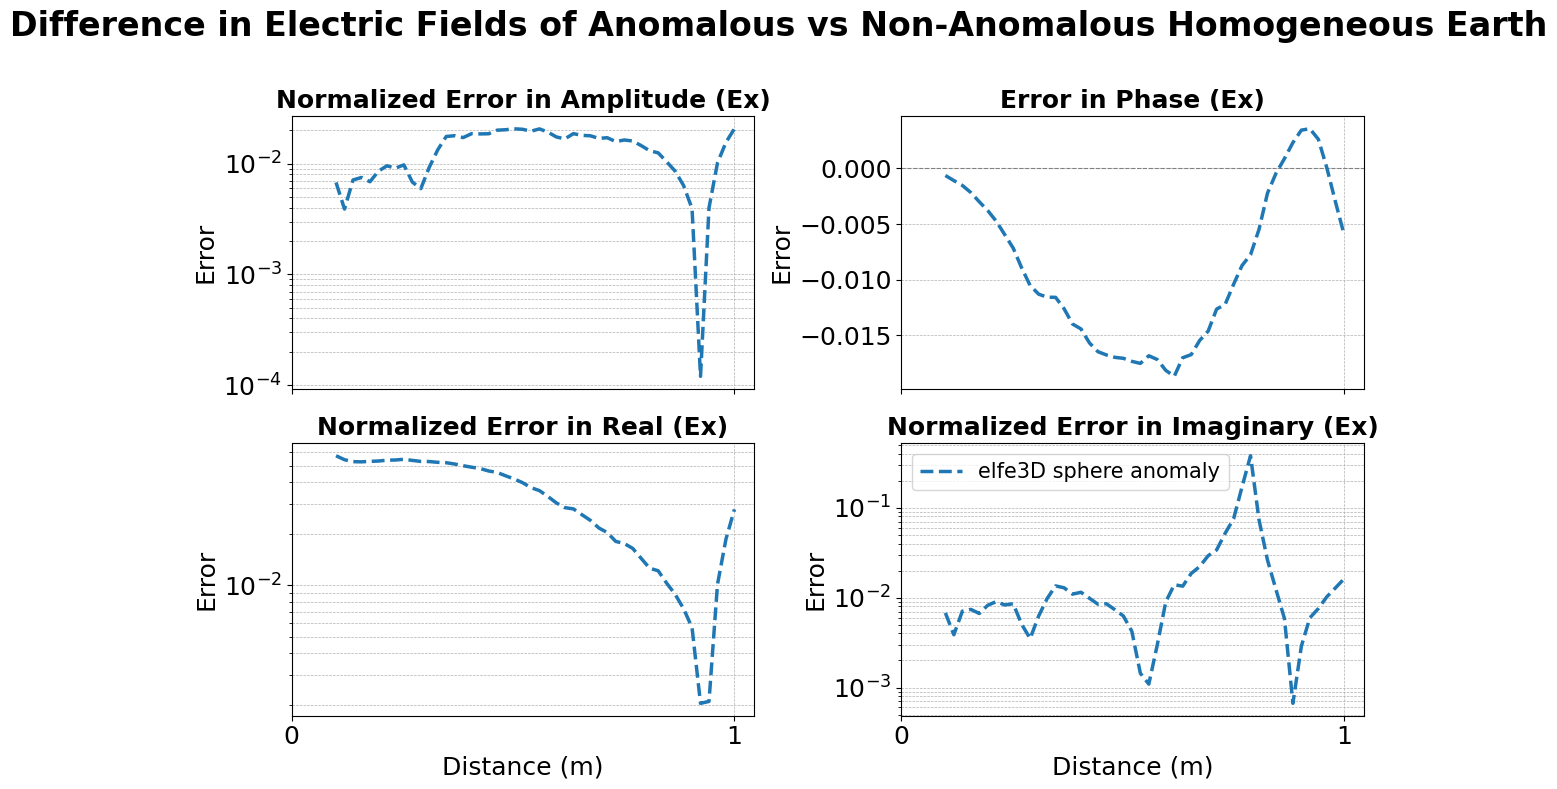

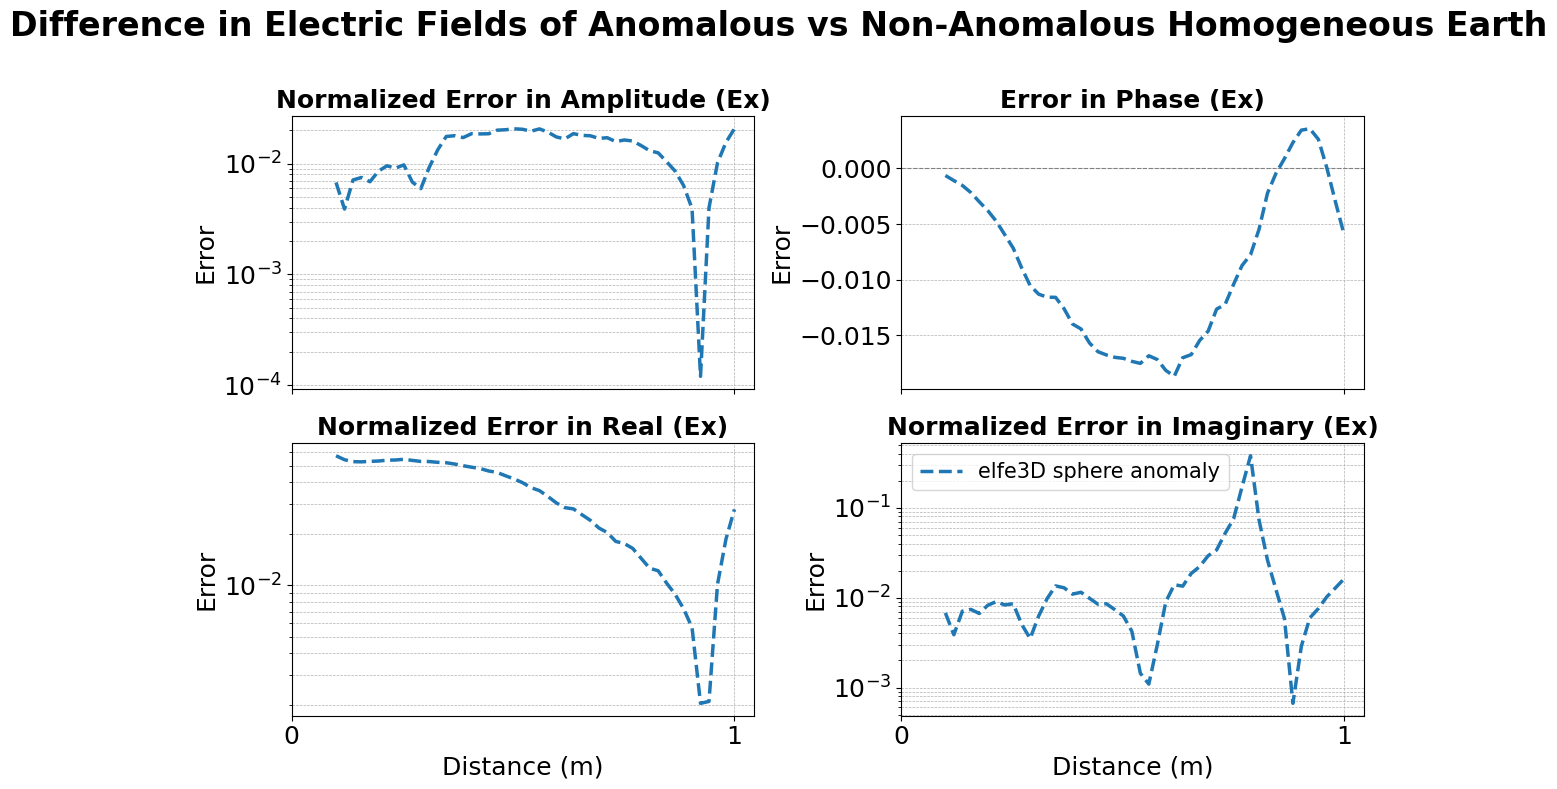

In [12]:
two_layered_txt = os.path.join(BASE_DIR, 'out_homogeneous_earth', 'electric_fields_receiver_line.txt')

tl = ElfeLoader(
    filepath    = str(two_layered_txt),
    label       = 'homogeneous earth',
    num_endfire = 48,
).endfire()

ReceiverLineErrorPlot([ef], reference=tl).plot(suptitle="Difference in Electric Fields of Anomalous vs Non-Anomalous Homogeneous Earth")

### Simple Errors (Not Normalized)

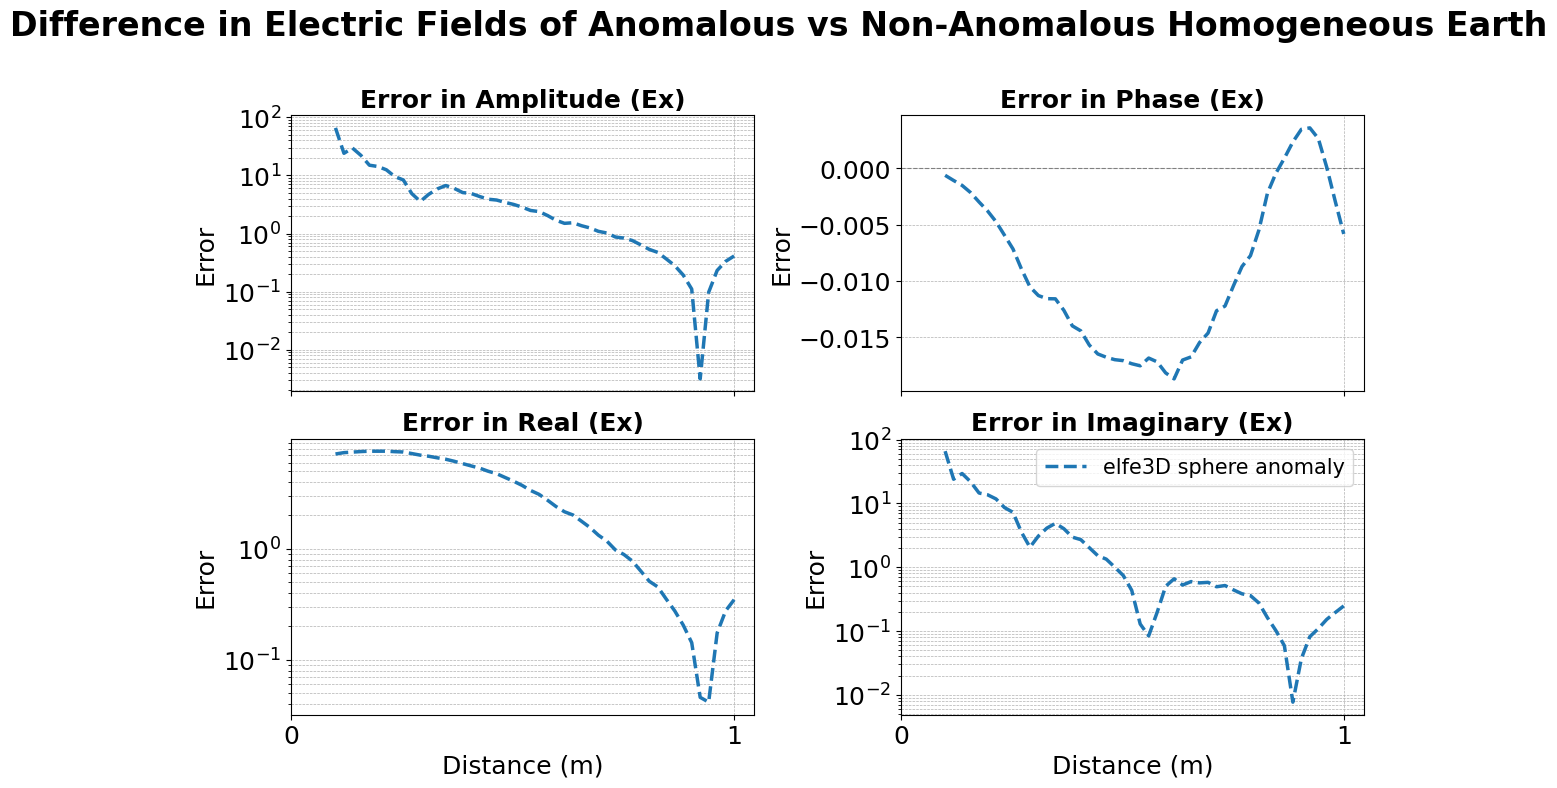

AttributeError: 'dict' object has no attribute 'label'

In [13]:
anomaly_elfe3D_GPR = ReceiverLineSimpleErrorPlot([ef], reference=tl)
anomaly_elfe3D_GPR.plot(suptitle="Difference in Electric Fields of Anomalous vs Non-Anomalous Homogeneous Earth")

anomaly_signature = anomaly_elfe3D_GPR.errors()

ReceiverLinePlot([anomaly_data, anomaly_signature]).plot(suptitle="Endfire - Homogeneous Earth")

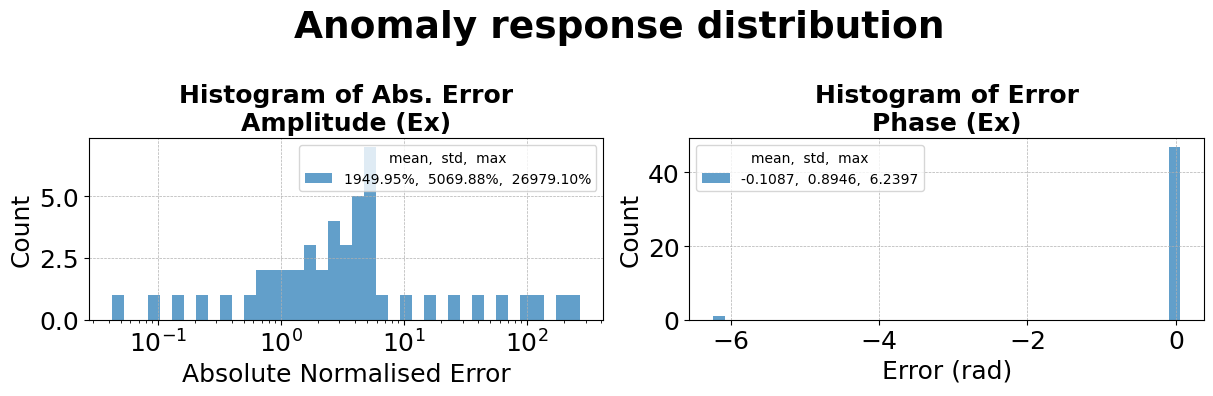

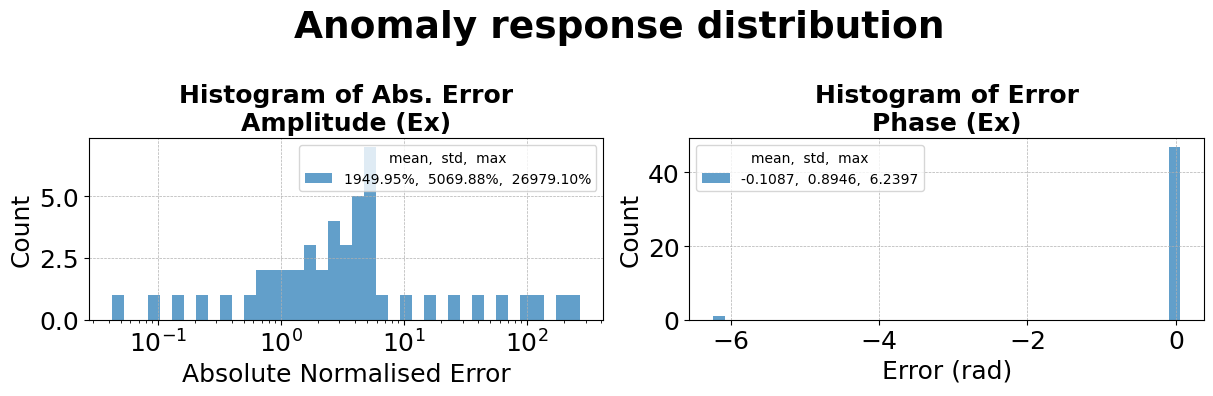

In [15]:
SimpleErrorHistogramPlot([ef], reference=bg).plot(suptitle='Anomaly response distribution',)

## miepython vs elfe3D_GPR Comparison with Normalized Maximum

In [16]:
# Load miepython endfire data
mie_endfire_loader = CSVFieldLoader(
    filepath=os.path.join(ANOMALY_DIR, 'endfire_electric_field.csv'),
    label='miepython (Endfire)',
    distance_col='Distance (m)',
    orientation='Endfire'
)
mie_endfire_raw = mie_endfire_loader.ex()

# Normalize to maximum value (keeping rest of data as-is)
def normalize_to_max(dataset: 'GPRDataset', suffix: str = "(normalized)") -> 'GPRDataset':
    """
    Normalize amplitude, real, and imaginary parts to same maximum.
    Phase remains unchanged (already dimensionless angle).
    """
    max_val = max(
        np.abs(dataset.amp).max(),
        np.abs(dataset.real).max(),
        np.abs(dataset.imag).max()
    )
    
    if max_val == 0:
        return dataset
    
    from elfe3d_gpr.outputs.fieldreader import GPRDataset
    return GPRDataset(
        amp=dataset.amp / max_val,
        phase=dataset.phase,  # Unchanged
        real=dataset.real / max_val,
        imag=dataset.imag / max_val,
        orientation=dataset.orientation,
        r=dataset.r,
        label=f"{dataset.label} {suffix}"
    )

# Normalize both datasets
mie_normalized = normalize_to_max(mie_endfire_raw, "(normalized)")
elfe_normalized = normalize_to_max(ef, "(normalized)")

print(f"miepython - max amplitude before: {mie_endfire_raw.amp.max():.4e}")
print(f"miepython - max amplitude after:  {mie_normalized.amp.max():.4e}")
print(f"\nelfe3D_GPR - max amplitude before: {ef.amp.max():.4e}")
print(f"elfe3D_GPR - max amplitude after:  {elfe_normalized.amp.max():.4e}")


miepython - max amplitude before: 1.2156e+12
miepython - max amplitude after:  1.0000e+00

elfe3D_GPR - max amplitude before: 9.8140e+03
elfe3D_GPR - max amplitude after:  1.0000e+00


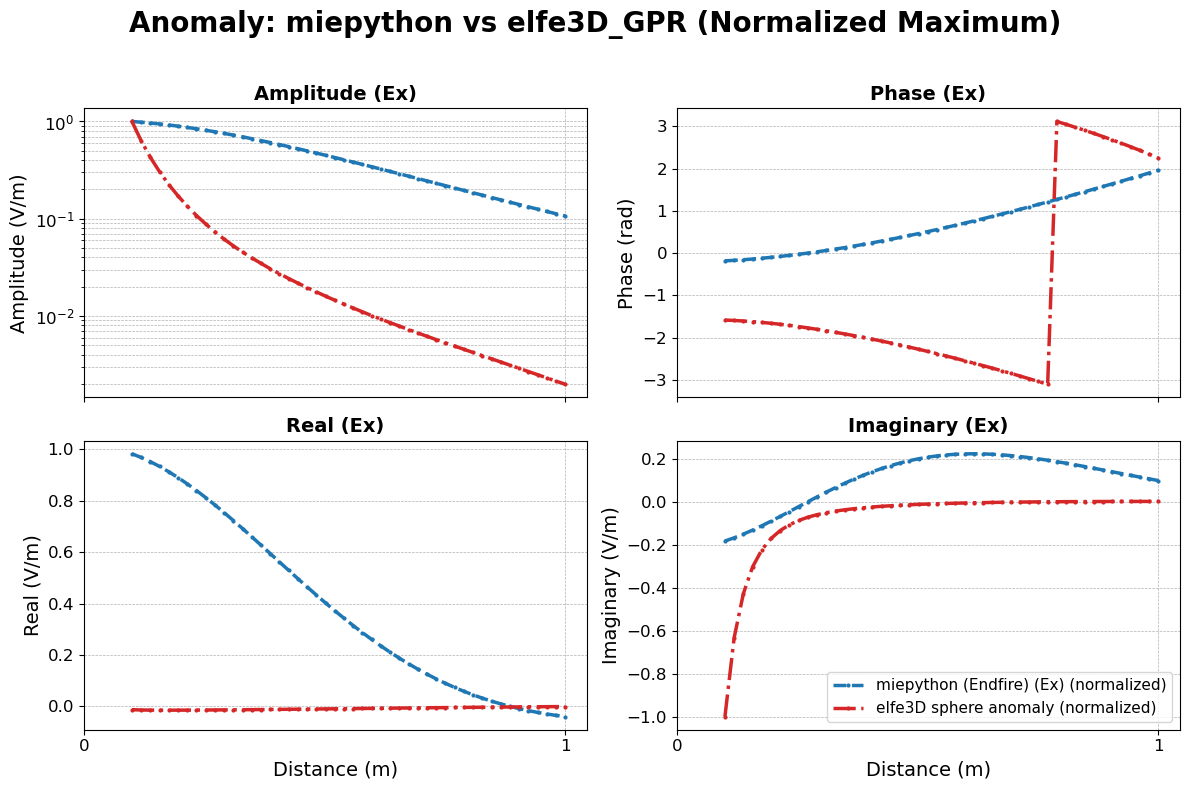

In [17]:
# Plot normalized comparison: Multi-dataset overlay (ReceiverLinePlot)
fig1 = ReceiverLinePlot(
    datasets=[mie_normalized, elfe_normalized],
    base_lw=2.5,
    font={"suptitle": 20, "label": 14, "tick": 12, "legend": 11},
    figsize=(12, 8)
).plot(suptitle="Anomaly: miepython vs elfe3D_GPR (Normalized Maximum)")


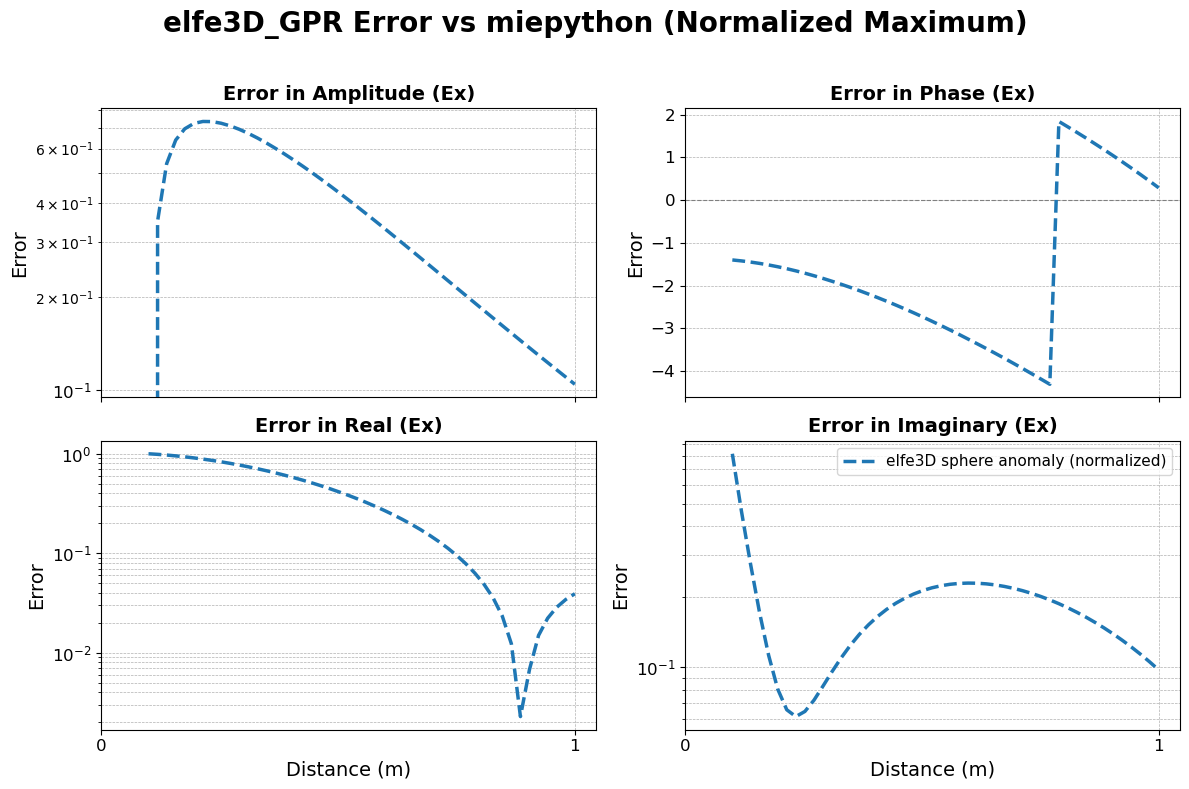


Error Statistics (elfe3D_GPR vs miepython, normalized)

elfe3D sphere anomaly (normalized):
  Amplitude   : max=  7.3394e+01%  mean=  3.8509e+01%  std=  2.1680e+01%
  Phase       : max=  1.8431e+00rad  mean= -1.6504e+00rad  std=  1.7805e+00rad
  Real        : max=  9.9666e+01%  mean=  4.0668e+01%  std=  3.3822e+01%
  Imaginary   : max=  8.1706e+01%  mean=  1.8306e+01%  std=  1.1555e+01%


In [18]:
# Plot normalized error: Error relative to reference (ReceiverLineSimpleErrorPlot)
error_plotter = ReceiverLineSimpleErrorPlot(
    datasets=[elfe_normalized],
    reference=mie_normalized,
    base_lw=2.5,
    font={"suptitle": 20, "label": 14, "tick": 12, "legend": 11},
    figsize=(12, 8)
)

error_plotter.plot(suptitle="elfe3D_GPR Error vs miepython (Normalized Maximum)")

# Print error statistics
errors_dict = error_plotter.errors()
print("\n" + "="*70)
print("Error Statistics (elfe3D_GPR vs miepython, normalized)")
print("="*70)
for dataset_name, quantities in errors_dict.items():
    print(f"\n{dataset_name}:")
    qty_names = ['Amplitude', 'Phase', 'Real', 'Imaginary']
    for i, (qty_name, error_array) in enumerate(zip(qty_names, quantities.values())):
        scale, unit = (100, '%') if i != 1 else (1, 'rad')
        print(f"  {qty_name:12s}: max={error_array.max()*scale:12.4e}{unit}  "
              f"mean={error_array.mean()*scale:12.4e}{unit}  "
              f"std={error_array.std()*scale:12.4e}{unit}")
